In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# --- 1. DATA LOADING ---
df = pd.read_csv('merged.csv')
df['Stock_Timestamp'] = pd.to_datetime(df['Stock_Timestamp'], utc=True)
df = df.sort_values('Stock_Timestamp').reset_index(drop=True)

# --- 2. FEATURE SELECTION (BASELINE OHLCV ONLY) ---
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Target: 1 if the NEXT minute's candle is green (Next Close > Next Open)
# This aligns with the slippage execution (Entry at T+1 Open, Exit at T+1 Close)
df['Target'] = (df['Close'].shift(-1) > df['Open'].shift(-1)).astype(int)

# Clean and prepare model data
model_df = df[feature_cols + ['Target']].dropna()

# --- 3. CHRONOLOGICAL SPLIT (70/20/10) ---
n = len(model_df)
train_idx = int(n * 0.70)
val_idx = int(n * 0.90) 

train_data = model_df.iloc[:train_idx]
val_data = model_df.iloc[train_idx:val_idx]
test_data = model_df.iloc[val_idx:]

# --- 4. SCALING (FIT ONLY ON TRAIN TO PREVENT LEAKAGE) ---
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data[feature_cols])
val_scaled = scaler.transform(val_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# Combine scaled features with targets
train_final = np.column_stack((train_scaled, train_data['Target'].values))
val_final = np.column_stack((val_scaled, val_data['Target'].values))
test_final = np.column_stack((test_scaled, test_data['Target'].values))

# --- 5. WINDOWING / SEQUENCE CREATION ---
def create_sequences(data, window_size=20):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :-1])
        y.append(data[i, -1])
    return np.array(X), np.array(y)

WINDOW_SIZE = 20
X_train, y_train = create_sequences(train_final, WINDOW_SIZE)
X_val, y_val = create_sequences(val_final, WINDOW_SIZE)
X_test, y_test = create_sequences(test_final, WINDOW_SIZE)

Epoch 1/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5004 - loss: 0.6939 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 2/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.4999 - loss: 0.6935 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 3/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5038 - loss: 0.6933 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 4/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5029 - loss: 0.6933 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 5/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5031 - loss: 0.6934 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 6/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5037 - loss: 0.6933 - val_accuracy: 0.5067 - val_loss: 0.6931
Epoch 7/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5032 - loss: 0.6932 - val_accuracy: 0.5067 - val_loss: 0.6931
Epoch 8/50
984/984 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5048 - loss: 0.6932 - 

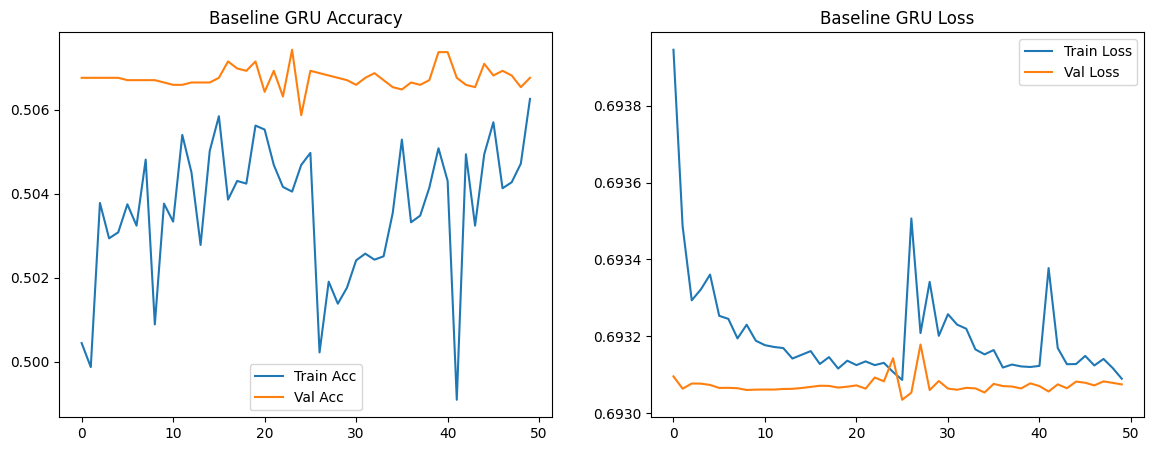

In [9]:
# --- 6. MODEL DEFINITION ---
def build_baseline_gru(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline_gru((X_train.shape[1], X_train.shape[2]))

# --- 7. TRAINING ---
history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    verbose=1
)

# --- 8. LOSS AND ACCURACY PLOTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train Acc'); ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Baseline GRU Accuracy'); ax1.legend()
ax2.plot(history.history['loss'], label='Train Loss'); ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Baseline GRU Loss'); ax2.legend()
plt.show()

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

       BASELINE STATISTICAL PERFORMANCE
Test Accuracy: 49.30%

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.49      0.41      0.45      4511
       Up (1)       0.49      0.58      0.53      4468

     accuracy                           0.49      8979
    macro avg       0.49      0.49      0.49      8979
 weighted avg       0.49      0.49      0.49      8979


       BASELINE FINANCIAL PERFORMANCE
Initial Capital:         $10,000.00
Total Net Profit:        $59.96
Final Capital:           $10,059.96
Total ROI:               0.60%


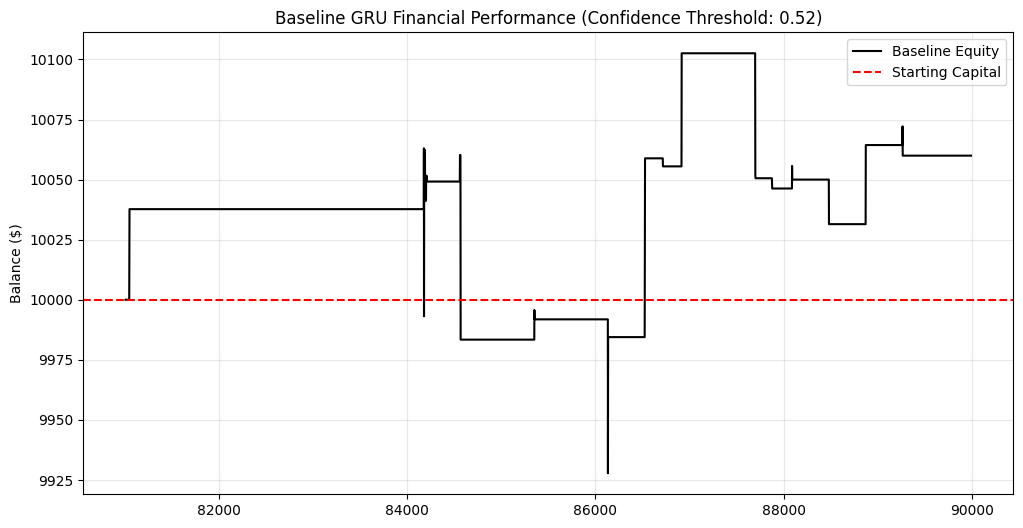

In [13]:
# --- 9. STATISTICAL EVALUATION ---
y_pred_probs = baseline_model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.50).astype(int)

print("\n" + "="*50)
print("       BASELINE STATISTICAL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down/Flat (0)', 'Up (1)']))

# --- 10. FINANCIAL EVALUATION (SLIPPAGE & COST) ---
# Align results with price data
df_results = test_data.iloc[WINDOW_SIZE:].copy()
df_results['Prob_Up'] = y_pred_probs
# Use a confidence threshold for signal generation
THRESHOLD = 0.52
df_results['Signal'] = (df_results['Prob_Up'] > THRESHOLD).astype(int)

# Slippage Model: Predict at T -> Entry at T+1 Open -> Exit at T+1 Close
df_results['Entry_Price'] = df_results['Open'].shift(-1)
df_results['Exit_Price'] = df_results['Close'].shift(-1)
df_results = df_results.dropna(subset=['Entry_Price', 'Exit_Price'])

# Financial constants
INITIAL_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009 
current_capital = INITIAL_CAPITAL
capital_history = []

for idx, row in df_results.iterrows():
    if row['Signal'] == 1:
        # Calculate shares based on current capital and entry price
        shares = np.floor(current_capital / row['Entry_Price'])
        # Gross profit using slippage prices
        gross_pnl = (row['Exit_Price'] - row['Entry_Price']) * shares
        # Total fees ($0.009 per share round-trip)
        fees = shares * FEE_PER_SHARE
        # Update capital
        current_capital += (gross_pnl - fees)
    
    capital_history.append(current_capital)

df_results['Equity'] = capital_history
total_profit = current_capital - INITIAL_CAPITAL

print("\n" + "="*50)
print("       BASELINE FINANCIAL PERFORMANCE")
print("="*50)
print(f"Initial Capital:         ${INITIAL_CAPITAL:,.2f}")
print(f"Total Net Profit:        ${total_profit:,.2f}")
print(f"Final Capital:           ${current_capital:,.2f}")
print(f"Total ROI:               {(total_profit/INITIAL_CAPITAL)*100:.2f}%")
print("="*50)

# --- 11. EQUITY CURVE ---
plt.figure(figsize=(12, 6))
plt.plot(df_results.index, df_results['Equity'], color='black', label='Baseline Equity')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Starting Capital')
plt.title(f'Baseline GRU Financial Performance (Confidence Threshold: {THRESHOLD})')
plt.ylabel('Balance ($)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()